In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR1, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots


# Loading files

In [3]:
filelist = "fits_ready/filelist_results-O.txt"

with open(filelist, "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]

In [4]:
bundles = {}

for name in names:
    bundles[name] = results_comp.load_line_bundle(
        name, name, MAPS_DIR1, read_header=True
    )

In [5]:
#bundles["LVM-30Dor-6563_subrot"]

In [6]:
dfs_obs  = {name: bundle["obs"]  for name, bundle in bundles.items()}
dfs_fit  = {name: bundle["fit"]  for name, bundle in bundles.items()}
meta_all = {name: bundle["meta"] for name, bundle in bundles.items()}

In [7]:
#dfs_obs["LVM-30Dor-6563_subrot"]

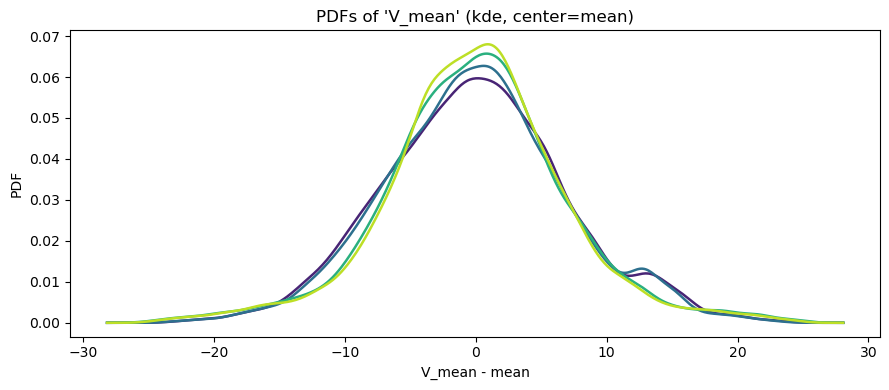

In [8]:
fig, ax, stats_df = list_maps_plots.plot_list_pdfs_circles(
    dfs_obs,
    col="V_mean",
    center="mean",
    method="kde",
    cmap="viridis",
    legend_mode="none",
    annotate=False,
    figsize=(9, 4),
    bw_scale=1.0
)

In [9]:
stats_df

,name,N,mean,std,var,xmin,xmax
0,LVM-30Dor-3729_subrot,20678,-6.428276,7.069710,49.980795,-23.405206,24.327150
1,LVM-30Dor-3729_rot,20678,263.632212,6.930397,48.030396,-23.400312,23.363788
2,LVM-30Dor-5007_subrot,20625,-4.991127,6.973751,48.633209,-25.633439,25.515826
3,LVM-30Dor-5007_rot,20625,265.069495,6.794545,46.165845,-24.941195,24.853305


In [10]:
#dfs_fit['LVM-30Dor-6563_subrot']

In [11]:
#labels = ['H_corr', 'H']
labels = [name.replace("LVM-30Dor-", "") for name in names]
labels

['3729_subrot', '3729_rot', '5007_subrot', '5007_rot']

In [12]:
#obs_var = [dfs_obs["LVM-30Dor-6563_subrot"]['V_mean'].var(), 
#           dfs_obs["LVM-30Dor-6563_rot"]['V_mean'].var()
#          ]
#obs_var
obs_var = [meta_all[name]["SIG2"] for name in names]

In [13]:
fit_tables = [dfs_fit[name] for name in names]

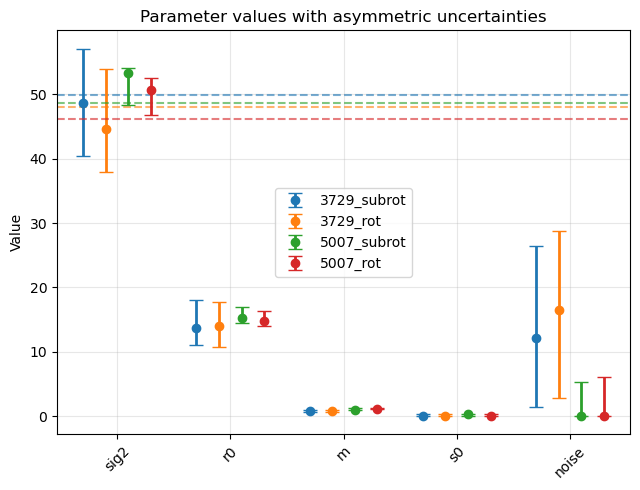

In [14]:
plot_fit_params.plot_param_comp_obs(
    *fit_tables,
    labels=labels,
    obs=obs_var
)

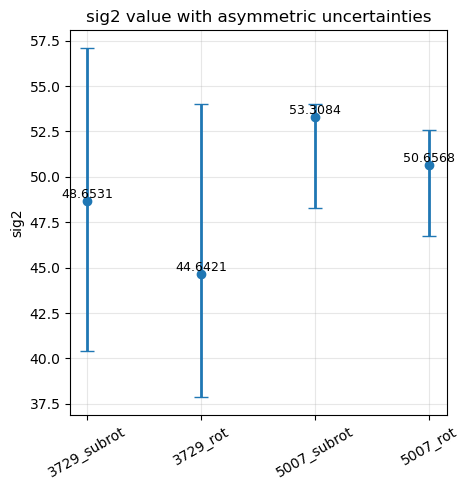

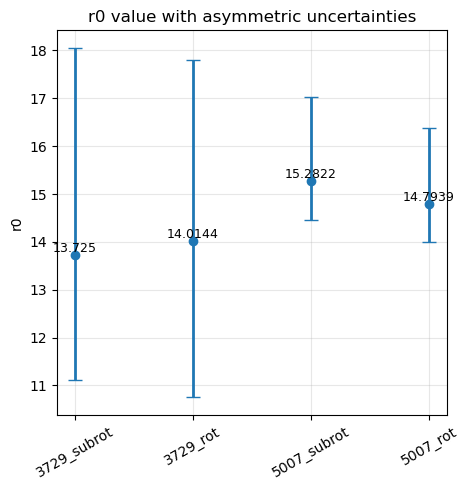

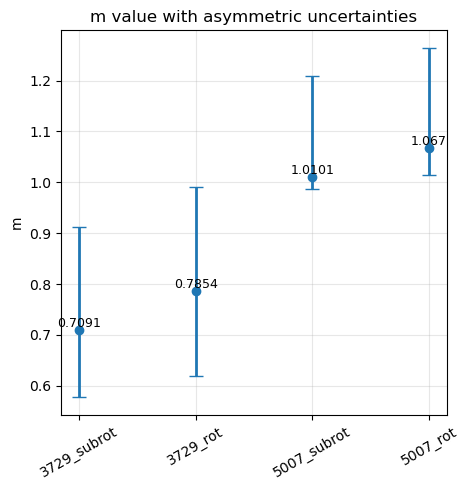

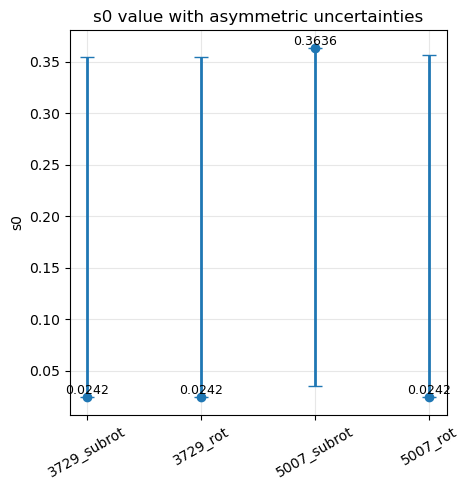

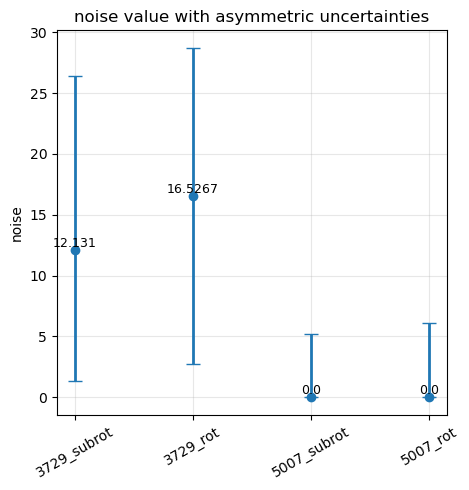

In [15]:
plot_fit_params.plot_param(
    *fit_tables,
    labels=labels,
    decimals=4
)

In [16]:
#plot_fit_params.plot_param(dfs_fit['LVM-30Dor-6563_rot'],
#                                    dfs_fit['LVM-30Dor-6563_subrot'], 
#                                    labels=labels,
#                                decimals=4)